# Лабораторная работа 5. Метод опорных векторов и деревья решений в задачах классификации и регрессии

## Примерная структура блокнота для задания 5

### Подготовка среды

In [1]:
# Импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Настройки отображения
plt.rcParams['figure.figsize'] = (8, 5)

### Задача 1. Базовая классификация на данных Iris

**Цель:** Применить три алгоритма к простому датасету и сравнить их базовую производительность.

### Инструкция:
1. Загрузите `load_iris`.
2. Разделите данные: 70% — обучающая выборка, 30% — тестовая выборка.
3. Обучите три модели:
   - **k-NN** (`k=3`)
   - **SVM** (`kernel='linear'`)
   - **Дерево решений** (по умолчанию)
4. **Важно:** Для k-NN и SVM примените `StandardScaler` к обучающим и тестовым данным.
5. Оцените **правильность** (`accuracy`) каждой модели на тесте.
6. Для дерева — визуализируйте его с помощью `plot_tree`.
7. Ответьте на вопрос, почему все три модели показывают почти 100% правильность на наборе ирисов?

k-NN (k=3): точность = 1.0000
SVM (linear): точность = 0.9778
Decision Tree: точность = 1.0000


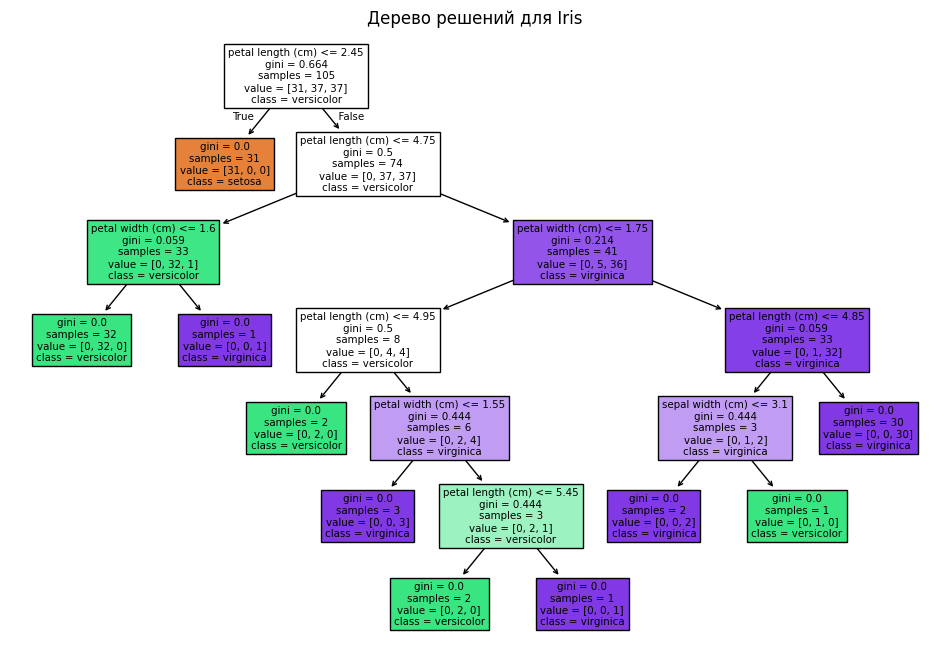

In [2]:
# 1. Загрузка данных
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Масштабирование (для k-NN и SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Модели
models = {
    "k-NN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "SVM (linear)": SVC(kernel='linear', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    # Выбираем масштабированные данные для k-NN и SVM
    X_tr = X_train_scaled if name in ["k-NN (k=3)", "SVM (linear)"] else X_train
    X_te = X_test_scaled if name in ["k-NN (k=3)", "SVM (linear)"] else X_test
    
    model.fit(X_tr, y_train)
    acc = model.score(X_te, y_test)
    results[name] = acc
    print(f"{name}: точность = {acc:.4f}")

plt.figure(figsize=(12, 8))
plot_tree(models["Decision Tree"], feature_names=load_iris().feature_names, class_names=load_iris().target_names, filled=True)
plt.title("Дерево решений для Iris")
plt.show()

### Задача 2. Влияние предобработки и гиперпараметров на данных Wine

**Цель:** Исследовать чувствительность моделей к масштабированию и настройке.

Инструкция:
1. Загрузите `load_wine`.
2. Разделите данные: 80% — обучающая выборка, 20% — тестовая выборка.
3. Выполните два эксперимента:
    1. SVM: с и без масштабирования
    2. Дерево: с ограничением глубины и без
4. Ответьте на вопрос, почему SVM сильно выигрывает от масштабирования, а дерево — нет?

In [3]:
# Загрузка и разделение данных Wine
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# A. SVM: с и без масштабирования
svm_no_scale = SVC(kernel='rbf', random_state=42)
svm_no_scale.fit(X_train, y_train)
acc_no = svm_no_scale.score(X_test, y_test)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
svm_scale = SVC(kernel='rbf', random_state=42)
svm_scale.fit(X_train_s, y_train)
acc_yes = svm_scale.score(X_test_s, y_test)

print(f"SVM без масштабирования: {acc_no:.4f}")
print(f"SVM с масштабированием:    {acc_yes:.4f}")

# B. Дерево решений
tree_full = DecisionTreeClassifier(random_state=42)
tree_limited = DecisionTreeClassifier(max_depth=3, random_state=42)

tree_full.fit(X_train, y_train)
tree_limited.fit(X_train, y_train)

print(f"Дерево (полное):   {tree_full.score(X_test, y_test):.4f}")
print(f"Дерево (глубина=3): {tree_limited.score(X_test, y_test):.4f}")

SVM без масштабирования: 0.8056
SVM с масштабированием:    1.0000
Дерево (полное):   0.9444
Дерево (глубина=3): 0.9444


### Задача 3. Подбор гиперпараметров с GridSearchCV на наборе Wine

**Цель:** Найти лучшие гиперпараметры для каждой модели.

In [4]:
# Подготовка данных (использовать из Задачи 2)
# X_train_s, X_test_s, y_train, y_test

# 1. k-NN
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': range(1, 21)},
    cv=5, scoring='accuracy'
)
knn_grid.fit(X_train_s, y_train)

# 2. SVM
svm_grid = GridSearchCV(
    SVC(random_state=42),
    {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    },
    cv=5, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X_train_s, y_train)

# 3. Дерево решений
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        'max_depth': [2, 3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    cv=5, scoring='accuracy'
)
tree_grid.fit(X_train, y_train)  # без масштабирования!

# Вывод лучших параметров
print("Лучший k-NN:", knn_grid.best_params_, "CV-точность:", round(knn_grid.best_score_, 4))
print("Лучший SVM:", svm_grid.best_params_, "CV-точность:", round(svm_grid.best_score_, 4))
print("Лучшее дерево:", tree_grid.best_params_, "CV-точность:", round(tree_grid.best_score_, 4))

Лучший k-NN: {'n_neighbors': 13} CV-точность: 0.9648
Лучший SVM: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'} CV-точность: 0.9788
Лучшее дерево: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2} CV-точность: 0.9224


### Задача 4. Сравнение трёх оптимизированных моделей

**Цель:** Сравнить модели по **точности**, **скорости обучения** и **интерпретируемости**.

       Модель  Точность (тест)  Время обучения (сек)
         k-NN           0.9722                0.0037
          SVM           1.0000                0.0021
Decision Tree           0.9444                0.0035


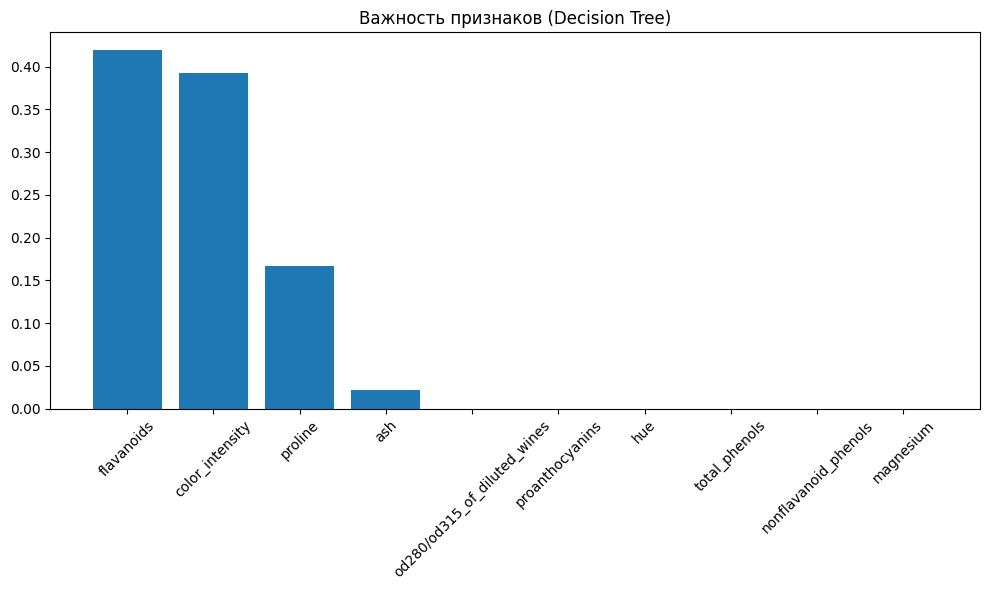

In [5]:
# Лучшие модели
best_knn = knn_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_tree = tree_grid.best_estimator_

# Данные
X_test_knn_svm = X_test_s  # масштабированные
X_test_tree = X_test       # оригинальные

models_final = {
    "k-NN": (best_knn, X_test_knn_svm),
    "SVM": (best_svm, X_test_knn_svm),
    "Decision Tree": (best_tree, X_test_tree)
}

comparison = []

for name, (model, X_test_m) in models_final.items():
    # Время обучения (повторное обучение для замера)
    X_train_m = X_train_s if name in ["k-NN", "SVM"] else X_train
    start = time.time()
    model.fit(X_train_m, y_train)
    train_time = time.time() - start
    
    # Точность на тесте
    test_acc = model.score(X_test_m, y_test)
    
    comparison.append({
        "Модель": name,
        "Точность (тест)": round(test_acc, 4),
        "Время обучения (сек)": round(train_time, 4)
    })

# Вывод таблицы
df_comp = pd.DataFrame(comparison)
print(df_comp.to_string(index=False))

# Важность признаков для дерева
feature_names = load_wine().feature_names
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Decision Tree)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45)
plt.tight_layout()
plt.show()

### Вопросы
1. Какая модель показала **наивысшую точность**?
> SVM RBF
3. Какая модель обучалась **быстрее всего**?
> KNN
4. Какая модель **наиболее интерпретируема**? Почему это важно в реальных задачах (медицина, финансы)?
> KNN, Дерево решений
5. Есть ли компромисс между точностью и интерпретируемостью?
> Дерево решений при правильной настройке параметров